In [127]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 

In [128]:
t_data=pd.read_csv("../data/train.csv")
#t_data.describe()

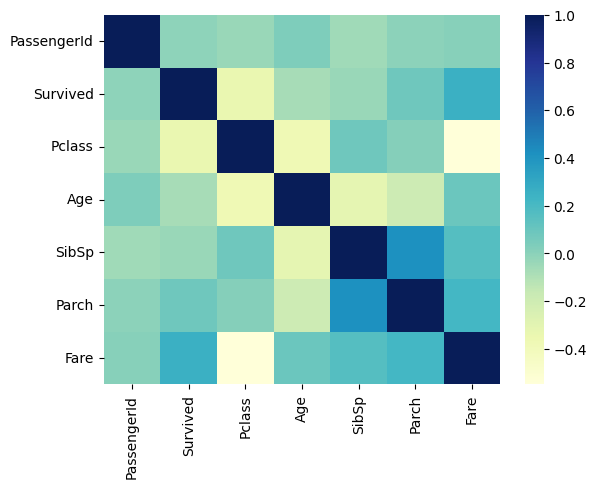

In [129]:
import seaborn as sns
sns.heatmap(t_data.corr(numeric_only=True),cmap="YlGnBu")
plt.show()

# exmpl
pclass 3->2->1  ==> Survived 0->1
Pclass ↔ Survived = -0.34

In [130]:
from sklearn.model_selection import StratifiedShuffleSplit
# the same position
split=StratifiedShuffleSplit(n_splits=1,test_size=0.2)

for train_index, test_index in split.split(t_data, t_data[["Survived","Pclass","Sex"]]):
    train_set = t_data.loc[train_index]
    test_set = t_data.loc[test_index]

Text(0.5, 1.0, 'test')

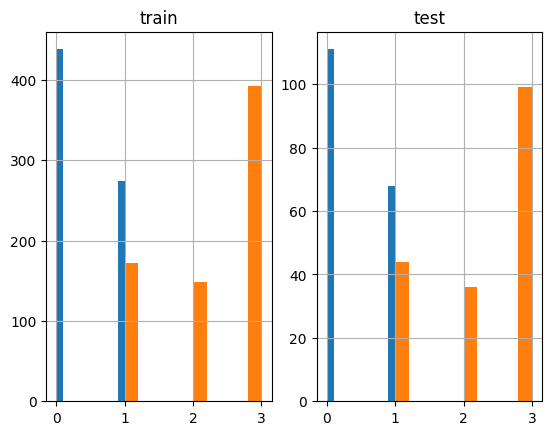

In [131]:
plt.subplot(1,2,1)
train_set['Survived'].hist()
train_set['Pclass'].hist()
plt.title("train")
#train_set['Sex'].hist()

plt.subplot(1,2,2)
test_set['Survived'].hist()
test_set['Pclass'].hist()
plt.title("test")

In [132]:
from sklearn.base import BaseEstimator,TransformerMixin
from sklearn.impute import SimpleImputer 

class AgeImputer(BaseEstimator,TransformerMixin):
    def fit(self,X,y=None):
        return self
    def transform(self,X):
        impute=SimpleImputer(strategy="mean")
        X['Age']=impute.fit_transform(X[['Age']])
        return X


In [133]:
from sklearn.preprocessing import OneHotEncoder


class FeatureEncode(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        encoder = OneHotEncoder()
        # station for start
        matrix = encoder.fit_transform(X[["Embarked"]]).toarray()
        colum_name = ["C", "S", "Q", "N"]
        for i in range(len(matrix.T)):
            X[colum_name[i]] = matrix.T[i]

        #Gender
        matrix = encoder.fit_transform(X[["Sex"]]).toarray()
        colum_name = ["female", "Male"]
        for i in range(len(matrix.T)):
            X[colum_name[i]] = matrix.T[i]

        return X

In [134]:
class FeatureDropper(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        return X.drop(
            ["Embarked", "Name", "Ticket", "Cabin", "Sex", "N"], axis=1, errors="ignore"
        )

In [135]:
from sklearn.pipeline import Pipeline

pipeline = Pipeline(
    [
        ("ageimputer", AgeImputer()),
        ("featureencoder", FeatureEncode()),
        ("featuredropper", FeatureDropper()),
    ]
)

In [136]:
train_set=pipeline.fit_transform(train_set)
train_set.info()

<class 'pandas.core.frame.DataFrame'>
Index: 712 entries, 356 to 488
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  712 non-null    int64  
 1   Survived     712 non-null    int64  
 2   Pclass       712 non-null    int64  
 3   Age          712 non-null    float64
 4   SibSp        712 non-null    int64  
 5   Parch        712 non-null    int64  
 6   Fare         712 non-null    float64
 7   C            712 non-null    float64
 8   S            712 non-null    float64
 9   Q            712 non-null    float64
 10  female       712 non-null    float64
 11  Male         712 non-null    float64
dtypes: float64(7), int64(5)
memory usage: 72.3 KB


In [137]:
from sklearn.preprocessing import StandardScaler

x = train_set.drop(["Survived"], axis=1)
y = train_set["Survived"]
print(x)

scaler = StandardScaler()
X_data = scaler.fit_transform(x)
y_data = y.to_numpy()

     PassengerId  Pclass        Age  SibSp  Parch     Fare    C    S    Q  \
356          357       1  22.000000      0      1  55.0000  0.0  0.0  1.0   
475          476       1  29.632875      0      0  52.0000  0.0  0.0  1.0   
636          637       3  32.000000      0      0   7.9250  0.0  0.0  1.0   
170          171       1  61.000000      0      0  33.5000  0.0  0.0  1.0   
253          254       3  30.000000      1      0  16.1000  0.0  0.0  1.0   
..           ...     ...        ...    ...    ...      ...  ...  ...  ...   
176          177       3  29.632875      3      1  25.4667  0.0  0.0  1.0   
272          273       2  41.000000      0      1  19.5000  0.0  0.0  1.0   
726          727       2  30.000000      3      0  21.0000  0.0  0.0  1.0   
50            51       3   7.000000      4      1  39.6875  0.0  0.0  1.0   
488          489       3  30.000000      0      0   8.0500  0.0  0.0  1.0   

     female  Male  
356     1.0   0.0  
475     0.0   1.0  
636     0.0   1

In [138]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

clf = RandomForestClassifier()
param_gird = [
    {
        "n_estimators": [10, 100, 200, 500],
        "max_depth": [None, 5, 10],
        "min_samples_split": [2, 3, 4],
    }
]
grid_search = GridSearchCV(
    clf, param_gird, cv=3, scoring="accuracy", return_train_score=True
)
grid_search.fit(X_data, y_data)

,estimator,RandomForestClassifier()
,param_grid,"[{'max_depth': [None, 5, ...], 'min_samples_split': [2, 3, ...], 'n_estimators': [10, 100, ...]}]"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,n_estimators,100


In [139]:
final_clf=grid_search.best_estimator_
final_clf

,n_estimators,100
,criterion,'gini'
,max_depth,10
,min_samples_split,3
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [140]:
test_set=pipeline.fit_transform(test_set)

In [141]:
X_test=test_set.drop(['Survived'],axis=1)
y_test=test_set['Survived']
scaler=StandardScaler()
X_data_test=scaler.fit_transform(X_test)
y_data_test=y_test.to_numpy()

In [142]:
final_clf.score(X_data_test,y_data_test)
final_data=pipeline.fit_transform(t_data)
X_final=final_data.drop(['Survived'],axis=1)
y_final=final_data['Survived']
scaler=StandardScaler()
X_data_final=scaler.fit_transform(X_final)
y_data_final=y_final.to_numpy()

In [143]:
pro_clf = RandomForestClassifier()
param_gird = [
    {
        "n_estimators": [10, 100, 200, 500],
        "max_depth": [None, 5, 10],
        "min_samples_split": [2, 3, 4],
    }
]
grid_search = GridSearchCV(
    pro_clf, param_gird, cv=3, scoring="accuracy", return_train_score=True
)
grid_search.fit(X_data_final, y_data_final)

,estimator,RandomForestClassifier()
,param_grid,"[{'max_depth': [None, 5, ...], 'min_samples_split': [2, 3, ...], 'n_estimators': [10, 100, ...]}]"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,n_estimators,200


In [144]:
pro_final_clf=grid_search.best_estimator_
pro_final_clf

,n_estimators,200
,criterion,'gini'
,max_depth,5
,min_samples_split,4
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [145]:
t_test_data=pd.read_csv("../data/test.csv")
final_test_data=pipeline.fit_transform(t_test_data)
final_test_data

,PassengerId,Pclass,Age,SibSp,Parch,Fare,C,S,Q,female,Male
0,892,3,34.50000,0,0,7.8292,0.0,1.0,0.0,0.0,1.0
1,893,3,47.00000,1,0,7.0000,0.0,0.0,1.0,1.0,0.0
2,894,2,62.00000,0,0,9.6875,0.0,1.0,0.0,0.0,1.0
3,895,3,27.00000,0,0,8.6625,0.0,0.0,1.0,0.0,1.0
4,896,3,22.00000,1,1,12.2875,0.0,0.0,1.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,30.27259,0,0,8.0500,0.0,0.0,1.0,0.0,1.0
414,1306,1,39.00000,0,0,108.9000,1.0,0.0,0.0,1.0,0.0
415,1307,3,38.50000,0,0,7.2500,0.0,0.0,1.0,0.0,1.0
416,1308,3,30.27259,0,0,8.0500,0.0,0.0,1.0,0.0,1.0


In [146]:
X_final_test=final_test_data
X_final_test=X_final_test.fillna(method="ffill")
scaler=StandardScaler()
X_data_final_test=scaler.fit_transform(X_final_test)
prediction=pro_final_clf.predict(X_data_final_test)
prediction

/tmp/ipykernel_735652/852301242.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  X_final_test=X_final_test.fillna(method="ffill")


array([0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0,
       1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1,
       1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1,
       1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1,
       1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1,
       1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1,
       0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1,
       0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0,

In [147]:
final_df=pd.DataFrame(t_test_data["PassengerId"])
final_df['Survived']=prediction
final_df.to_csv("../data/predictions.csv",index=False)
final_df

,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1
...,...,...
413,1305,0
414,1306,1
415,1307,0
416,1308,0
